This is a simple notebook to assist with quick visualization of the indices dataset.

In [27]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

data_dir = Path("snap/drought_outputs")

all_files = [#Path('snap/drought_outputs/drought_indices_1day.nc'),
         Path('snap/drought_outputs/drought_indices_7day.nc'),
         Path('snap/drought_outputs/drought_indices_30day.nc'),
         Path('snap/drought_outputs/drought_indices_60day.nc'),
         Path('snap/drought_outputs/drought_indices_90day.nc'),
         Path('snap/drought_outputs/drought_indices_180day.nc'),
         Path('snap/drought_outputs/drought_indices_365day.nc')]

PLOT_VARS = ["tp", "pntp", "swe", "pnswe", "spi", "spei", "smd"]

CMAPS: dict[str, str] = {
    "tp": "Blues",
    "pntp": "Blues",
    "swe": "PuBu",
    "pnswe": "PuBu",
    "spi": "RdBu",
    "spei": "RdBu",
    "smd": "YlGn",
}

"""Lookup tables for processing the drought indices"""

varname_prefix_lu = {
    "tp": "total_precipitation",
    "sd": "snow_depth",
    "swvl1": "volumetric_soil_water_layer_1",
    "swvl2": "volumetric_soil_water_layer_2",
    "pev": "potential_evaporation",
}

index_lu = {
    "tp": "Total Precipitation (cm)",
    "pntp": "Total Precipitation % of Normal",
    "swe": "Snow Water Equivalent (cm)",
    "pnswe": "Snow Water Equivalent % of Normal",
    "spi": "Standardized Precipitation Index",
    "spei": "Standardized Precipitation Evapotranspiration Index",
    "smd": "Soil Moisture Deficit (%)"
}

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# Define categories (percentage of normal)
# 0-20, 20-40, 40-60, 60-70, 70-100, >100
bounds = [0, 20, 40, 60, 70, 100, 200]  # upper bound 200 covers >100%
# Choose distinct colors (choose any palette you like)
colors = [
    "#7f0000",  # <20% (very dry) - dark red
    "#d73027",  # 20-40% - red
    "#fc8d59",  # 40-60% - orange
    "#fee08b",  # 60-70% - yellow
    "#91cf60",  # 70-100% - light green
    "#1a9850",  # >100% - green
]

cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N, clip=True)

In [28]:
short_window_files = [all_files[0]]
short_window_files

[PosixPath('snap/drought_outputs/drought_indices_1day.nc')]

In [29]:
long_window_files = all_files[1::]
long_window_files

[PosixPath('snap/drought_outputs/drought_indices_7day.nc'),
 PosixPath('snap/drought_outputs/drought_indices_30day.nc'),
 PosixPath('snap/drought_outputs/drought_indices_60day.nc'),
 PosixPath('snap/drought_outputs/drought_indices_90day.nc'),
 PosixPath('snap/drought_outputs/drought_indices_180day.nc'),
 PosixPath('snap/drought_outputs/drought_indices_365day.nc')]

In [30]:
def open_nc(path: str | Path) -> xr.Dataset:
    """Open a NetCDF file with decoding enabled."""
    return xr.open_dataset(path)


def get_xy(ds: xr.Dataset) -> tuple[np.ndarray, np.ndarray]:
    """Return 1D longitude and latitude coordinates."""
    lon_name = "longitude" if "longitude" in ds.coords or "longitude" in ds.variables else "lon"
    lat_name = "latitude" if "latitude" in ds.coords or "latitude" in ds.variables else "lat"

    lon = ds[lon_name].values
    lat = ds[lat_name].values
    return lon, lat


def get_plot_vars(ds: xr.Dataset, candidates: list[str] | None = None) -> list[str]:
    """Return variables that are 2D latitude-longitude fields."""
    candidates = candidates or list(ds.data_vars)

    valid: list[str] = []
    for var in candidates:
        if var not in ds.data_vars:
            continue
        dims = set(ds[var].dims)
        if dims == {"latitude", "longitude"} or dims == {"lat", "lon"}:
            valid.append(var)
    return valid


def get_title(path: str | Path, var: str, da: xr.DataArray) -> str:
    """Build a readable subplot title."""
    long_name = da.attrs.get("long_name", var)
    units = da.attrs.get("units", "")
    stem = Path(path).stem
    if units:
        return f"{stem}\n{long_name} [{units}]"
    return f"{stem}\n{long_name}"


def plot_da_on_ax(
    ax: plt.Axes,
    da: xr.DataArray,
    lon: np.ndarray,
    lat: np.ndarray,
    *,
    cmap: str = "viridis",
    robust: bool = True,
    symmetric: bool = False,
) -> None:
    """Plot a single 2D DataArray on an axis."""
    data = da.values

    vmin = vmax = None
    if robust:
        finite = np.asarray(data[np.isfinite(data)])
        if finite.size:
            if symmetric:
                q = np.nanpercentile(np.abs(finite), 98)
                vmin, vmax = -q, q
            else:
                vmin, vmax = np.nanpercentile(finite, [2, 98])

    if symmetric and (vmin is None or vmax is None):
        finite = np.asarray(data[np.isfinite(data)])
        if finite.size:
            q = np.nanmax(np.abs(finite))
            vmin, vmax = -q, q

    mesh = ax.pcolormesh(
        lon,
        lat,
        data,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    plt.colorbar(mesh, ax=ax, shrink=0.85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")


In [31]:
def plot_variable_across_files(
    paths: list[str | Path],
    variable: str,
    *,
    ncols: int = 3,
    figsize_per_panel: tuple[float, float] = (6.0, 4.0),
    save_path: str | Path | None = None,
) -> plt.Figure:
    """Compare the same variable across multiple NetCDF files."""
    if not paths:
        raise ValueError("No input files provided.")

    nrows = ceil(len(paths) / ncols)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        constrained_layout=True,
        squeeze=False,
    )

    # Use common scaling across files
    arrays: list[np.ndarray] = []
    opened: list[tuple[Path, xr.Dataset]] = []
    for path in paths:
        p = Path(path)
        ds = open_nc(p)
        opened.append((p, ds))
        arrays.append(ds[variable].values)
            
    stacked = np.stack(arrays)
    finite = stacked[np.isfinite(stacked)]

    symmetric = variable in {"spi", "spei"}
    if symmetric:
        vmin=-2
        vmax=2
    # if finite.size:
    #     if symmetric:
    #         q = np.nanpercentile(np.abs(finite), 98)
    #         vmin, vmax = -q, q
    #     else:
    #         vmin, vmax = np.nanpercentile(finite, [2, 98])
    else:
        vmin = vmax = None

    cmap = CMAPS.get(variable, "viridis")

    for ax, (path, ds) in zip(axes.flat, opened, strict=False):
        lon, lat = get_xy(ds)
        da = ds[variable]

        mesh = ax.pcolormesh(
            lon,
            lat,
            da.values,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(Path(path).stem.split("_")[-1])
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        plt.colorbar(mesh, ax=ax, shrink=0.85)

    for ax in axes.flat[len(opened):]:
        ax.axis("off")

    fig.suptitle(index_lu[variable], fontsize=12)
    if save_path is not None:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")

    #return fig

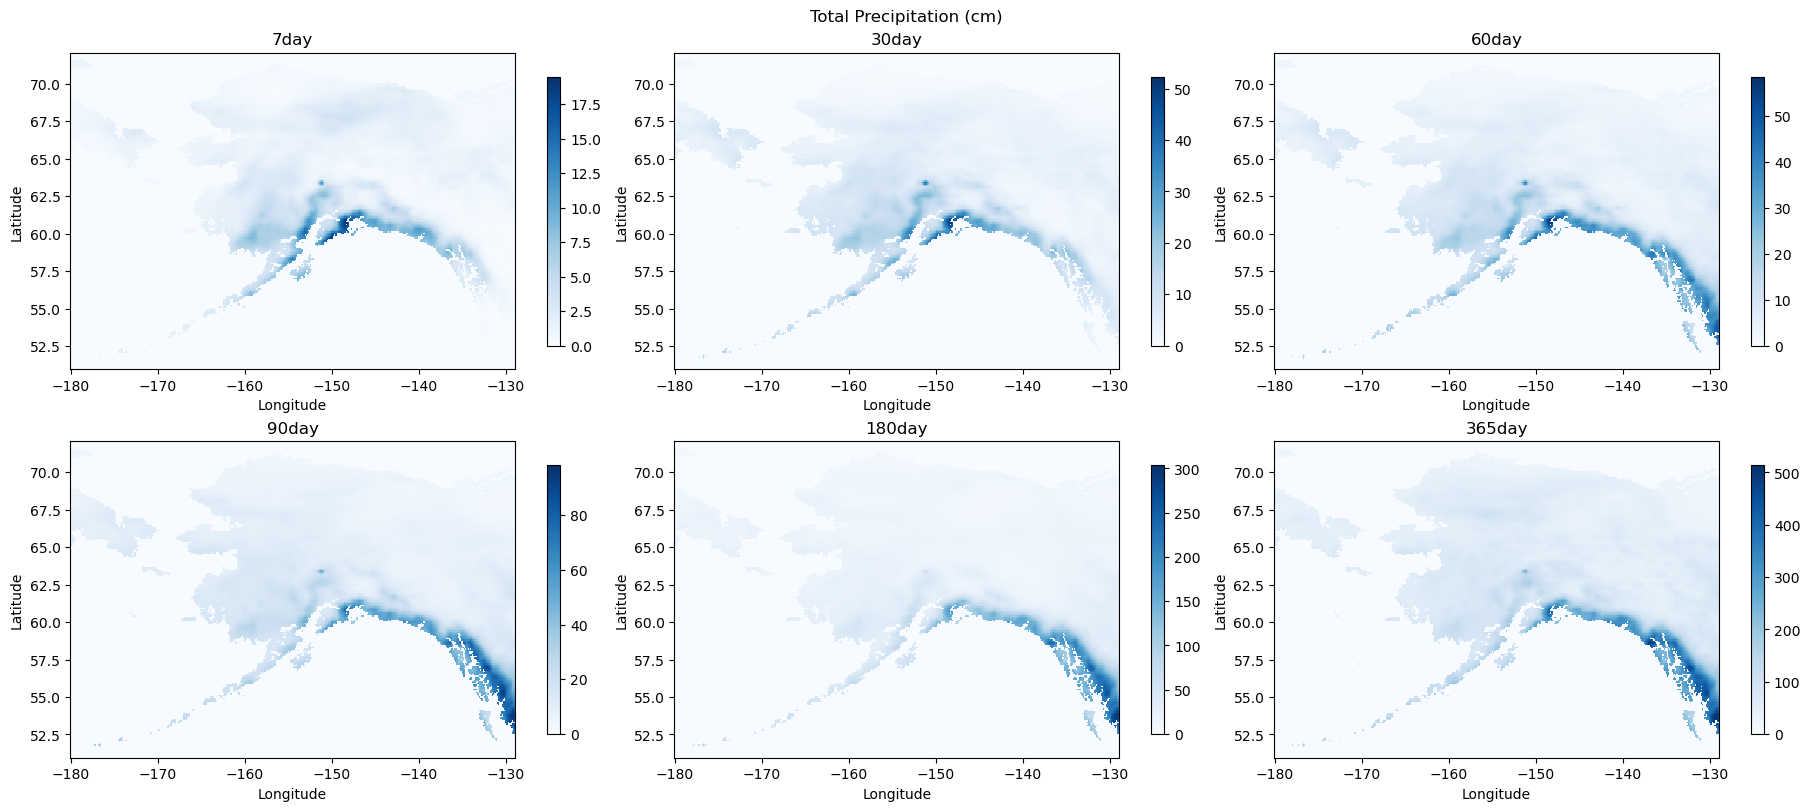

In [32]:
plot_variable_across_files(long_window_files, "tp")

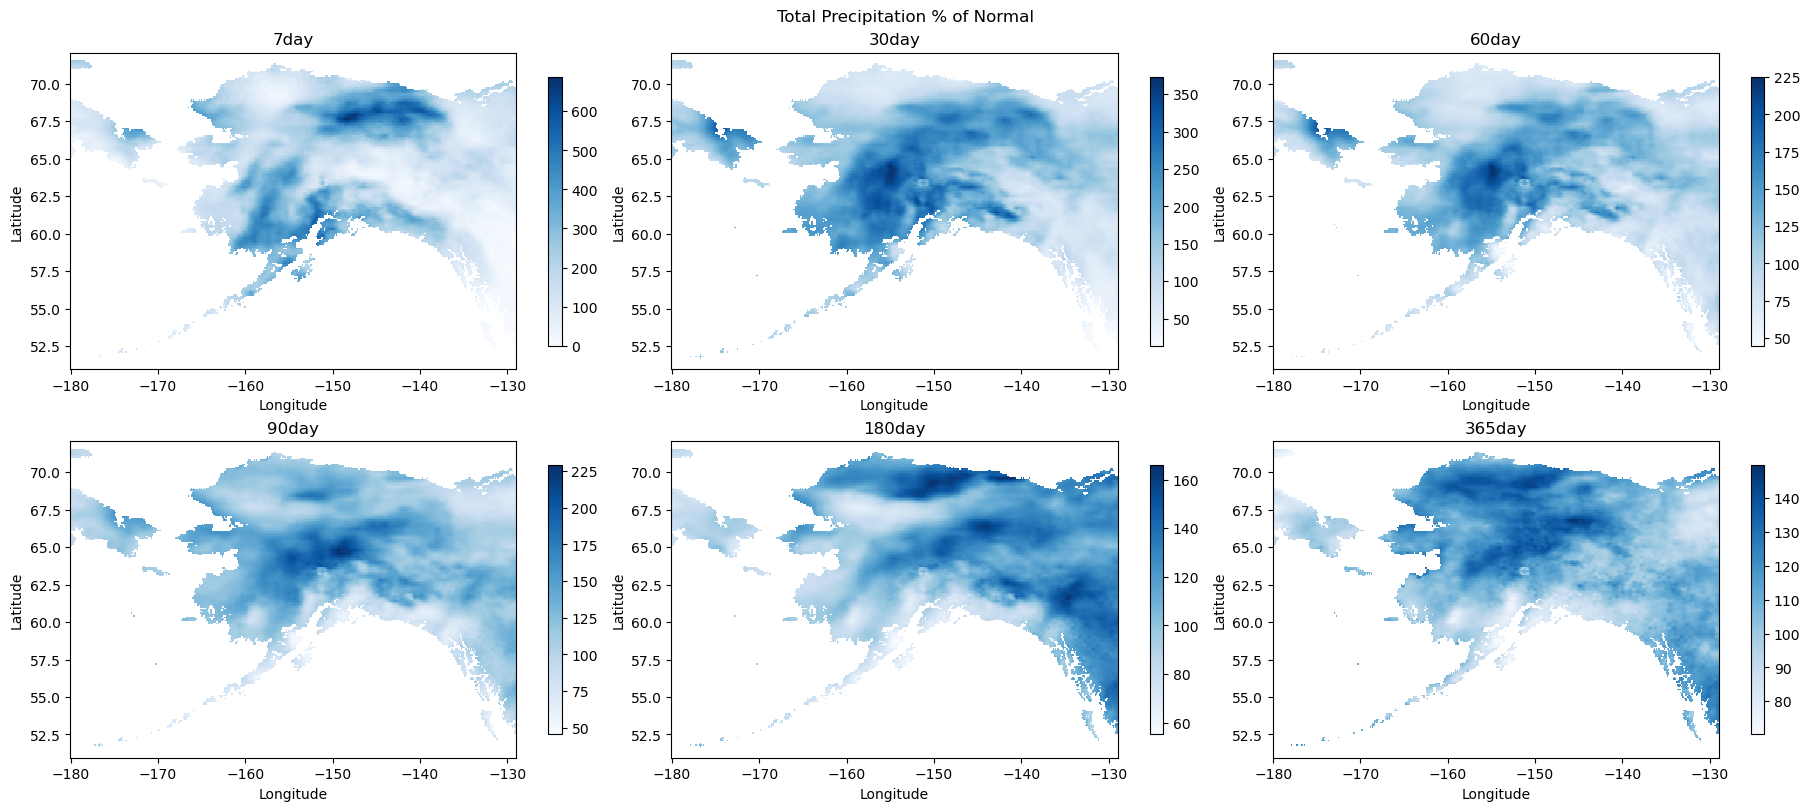

In [33]:
plot_variable_across_files(long_window_files, "pntp")

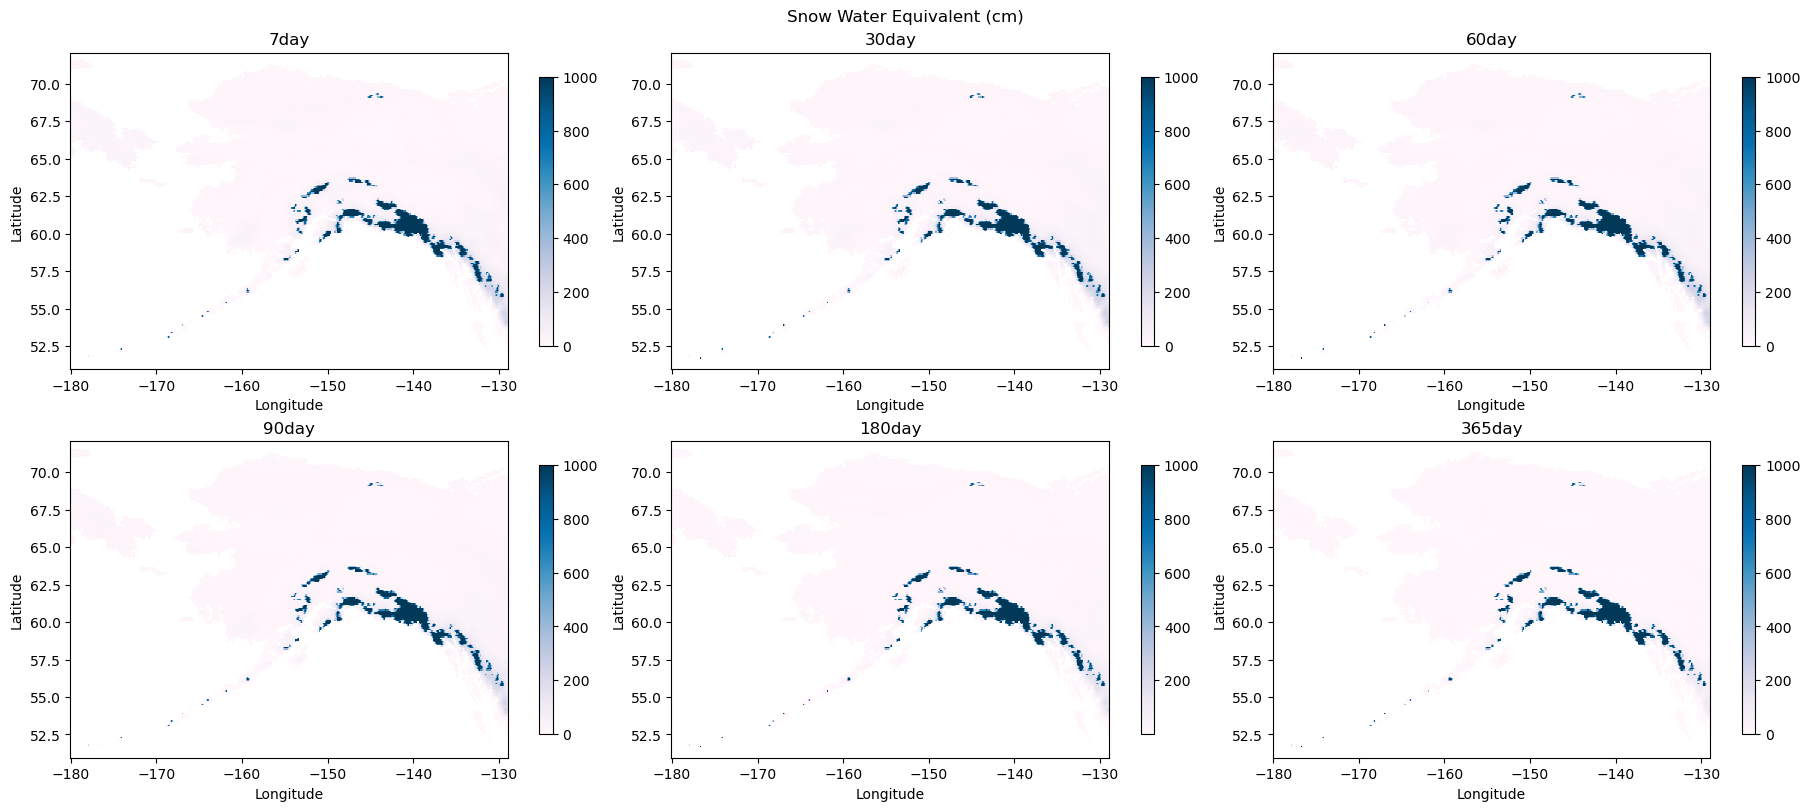

In [34]:
plot_variable_across_files(long_window_files, "swe")

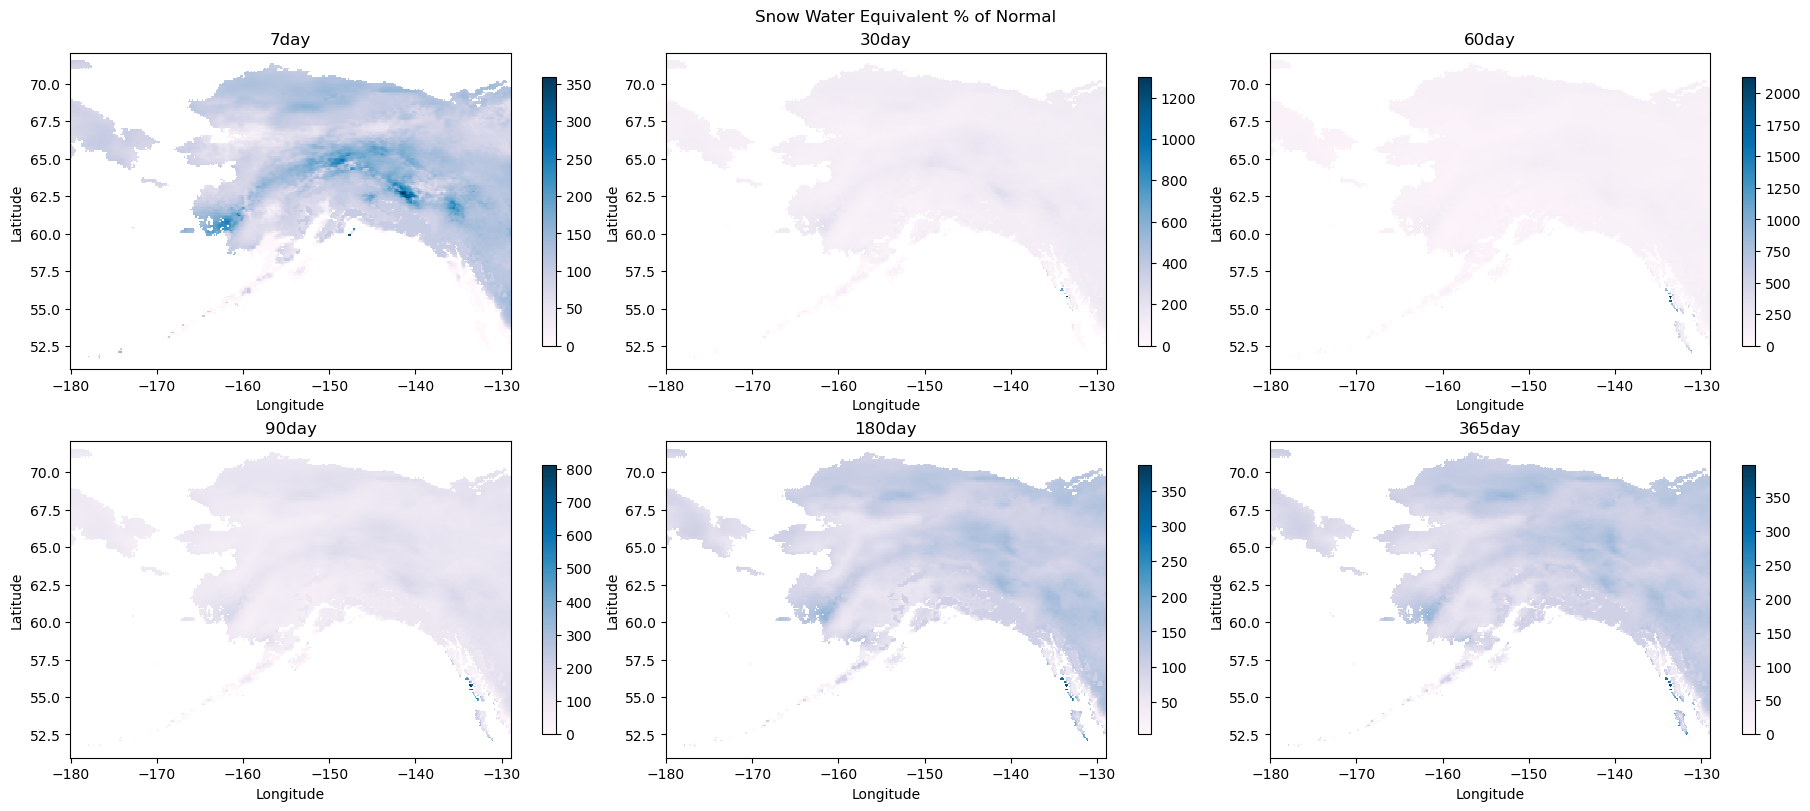

In [35]:
plot_variable_across_files(long_window_files, "pnswe")

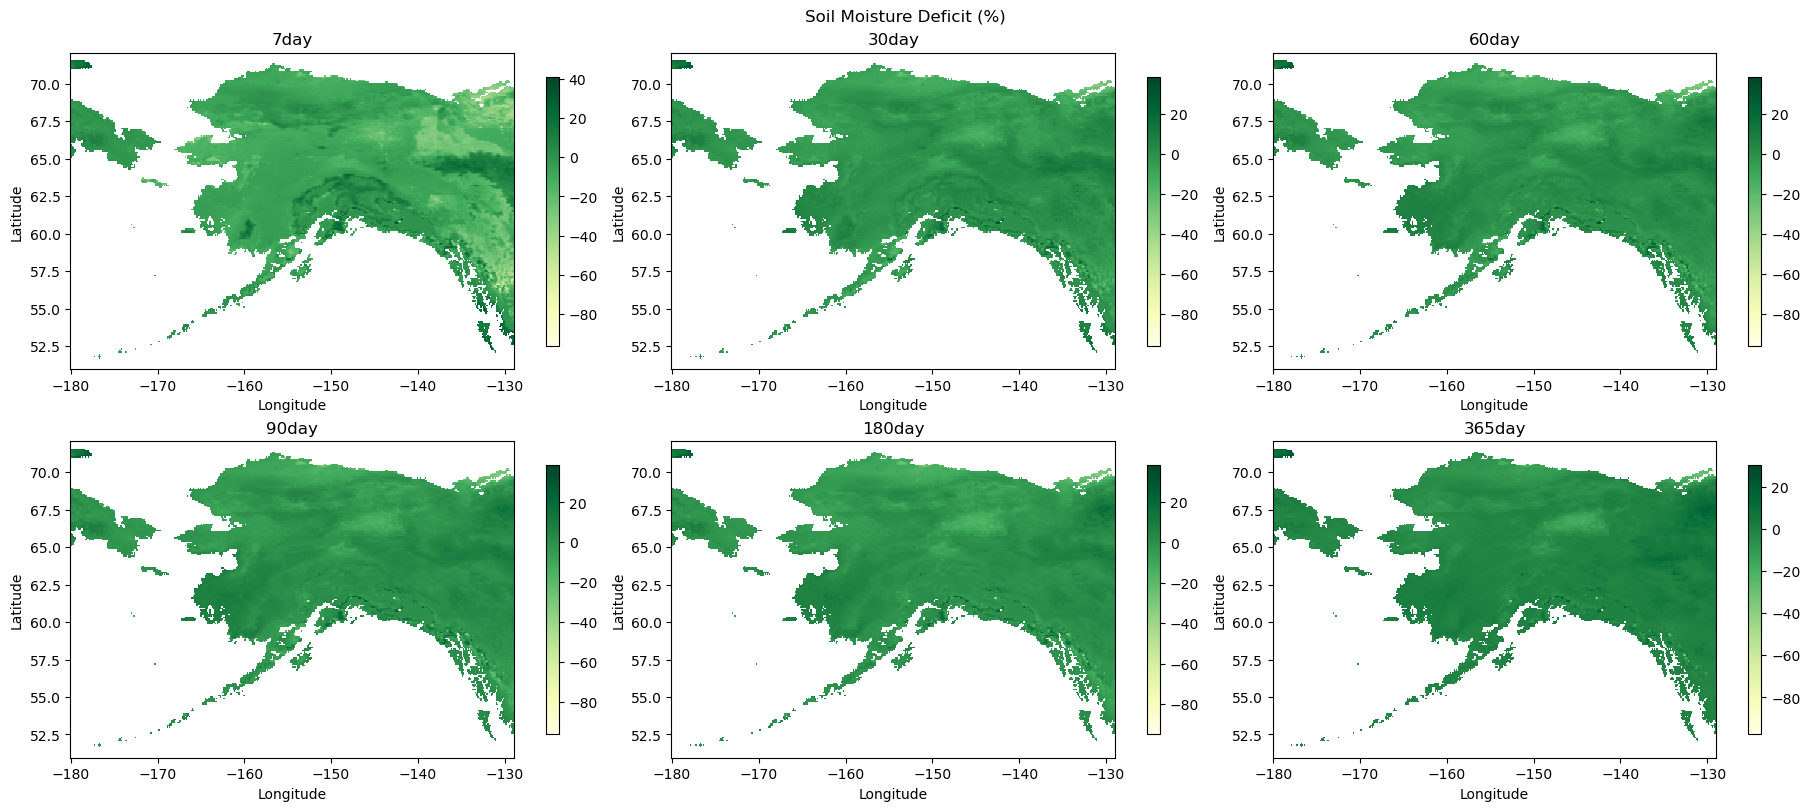

In [36]:
plot_variable_across_files(long_window_files, "smd")

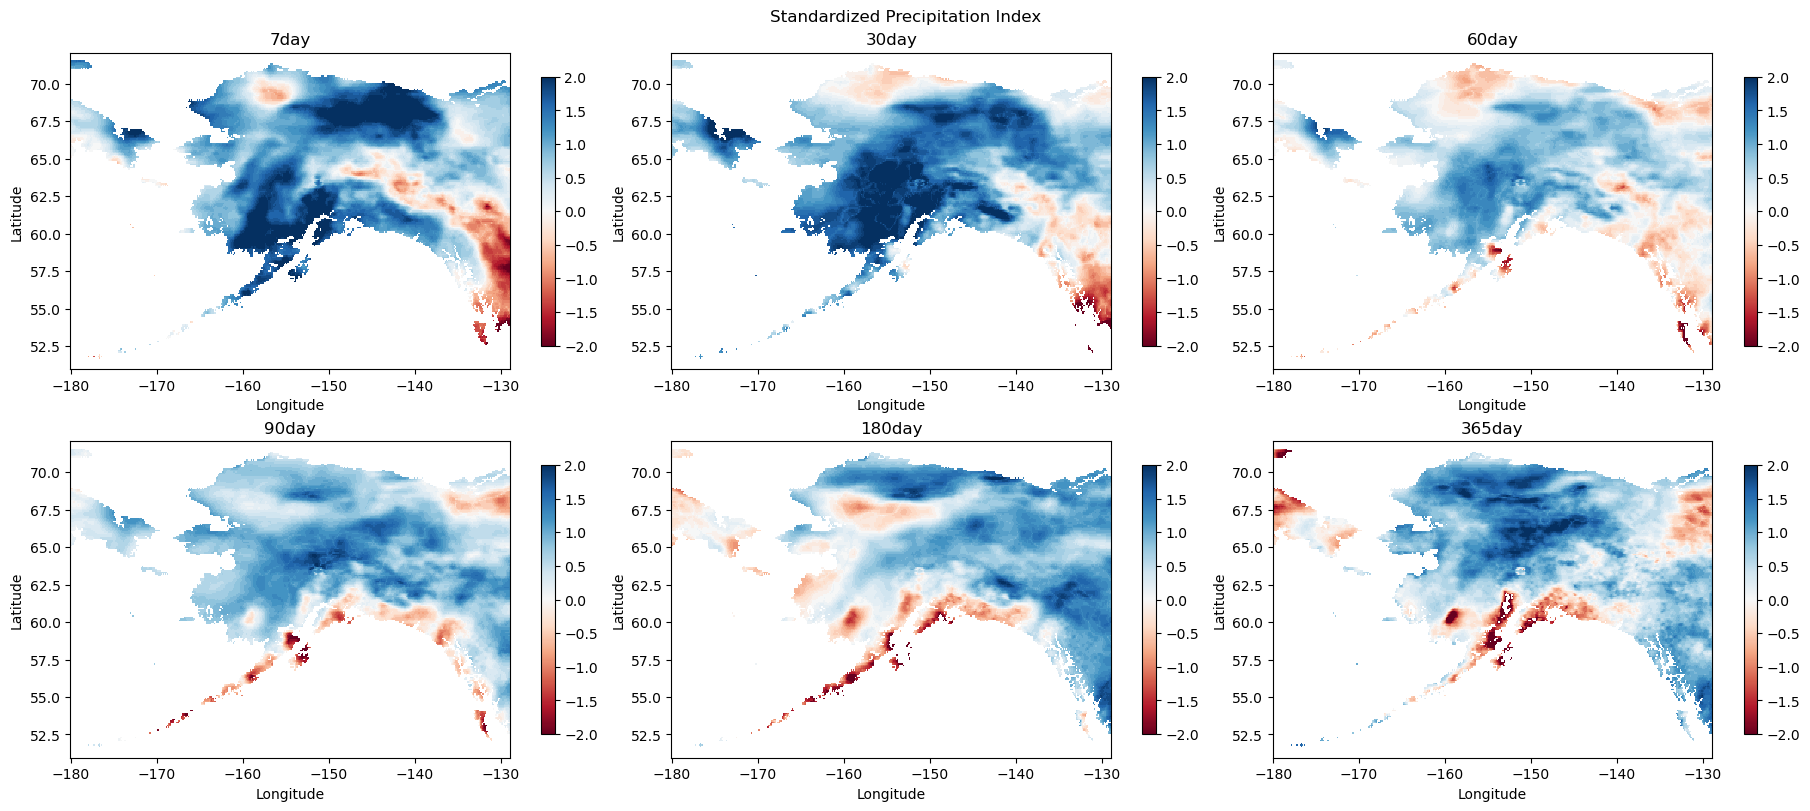

In [37]:
plot_variable_across_files(long_window_files, "spi")

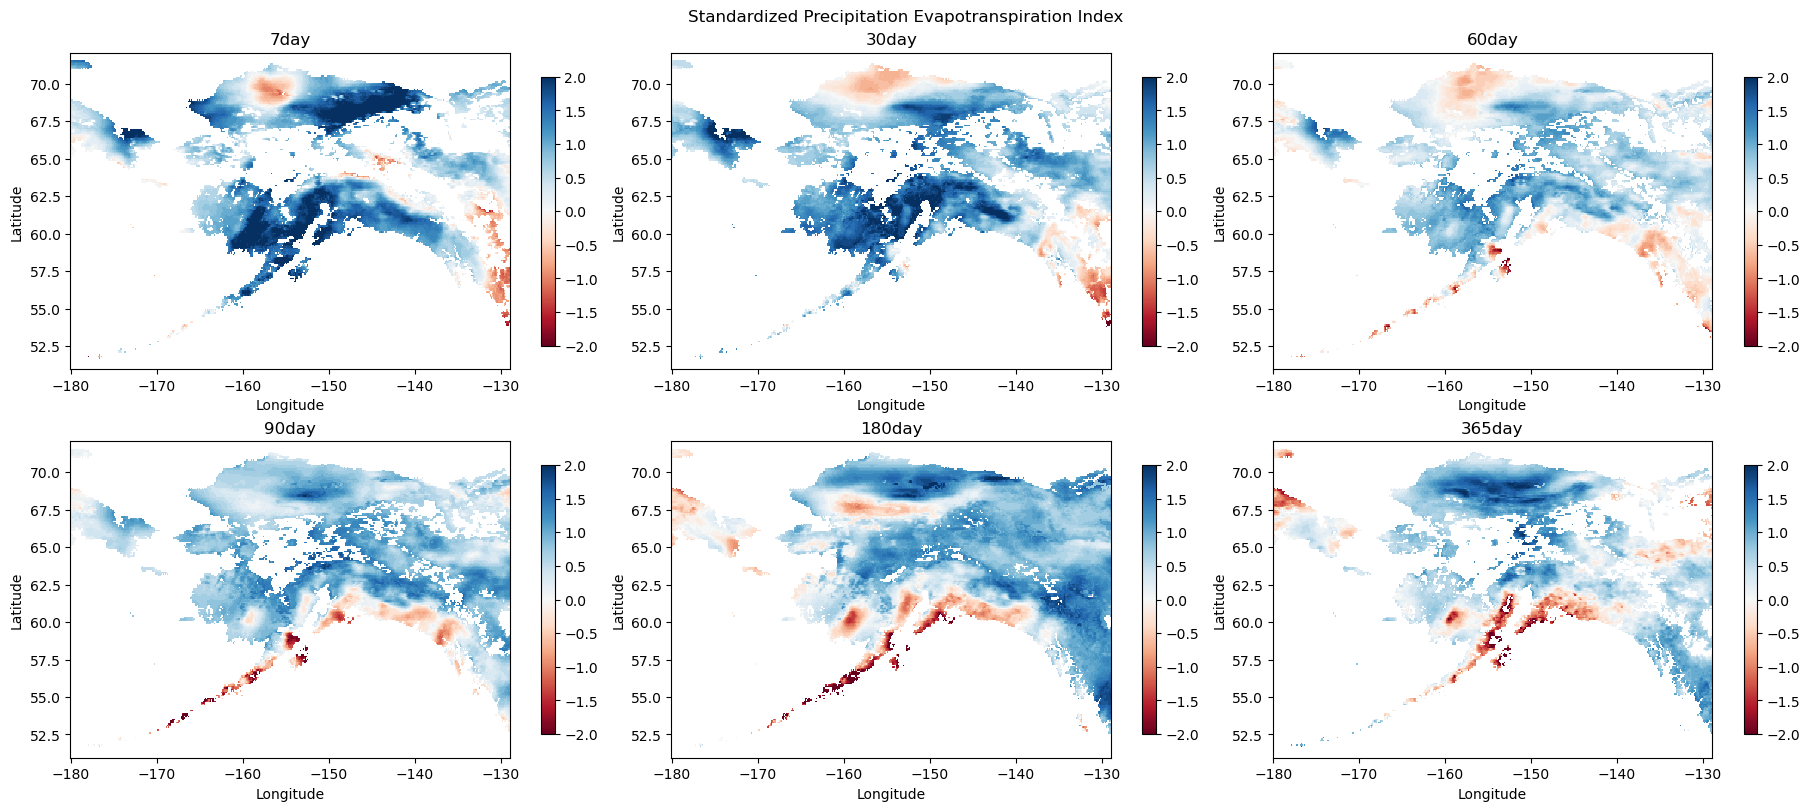

In [38]:
plot_variable_across_files(long_window_files, "spei")

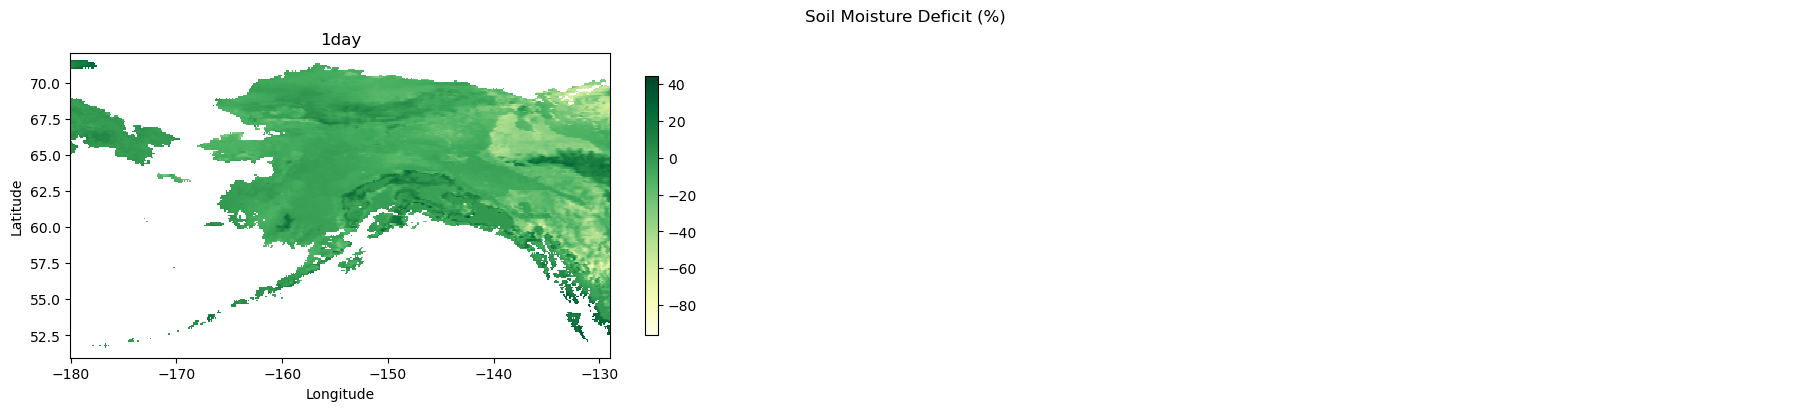

In [39]:
plot_variable_across_files(short_window_files, "smd")

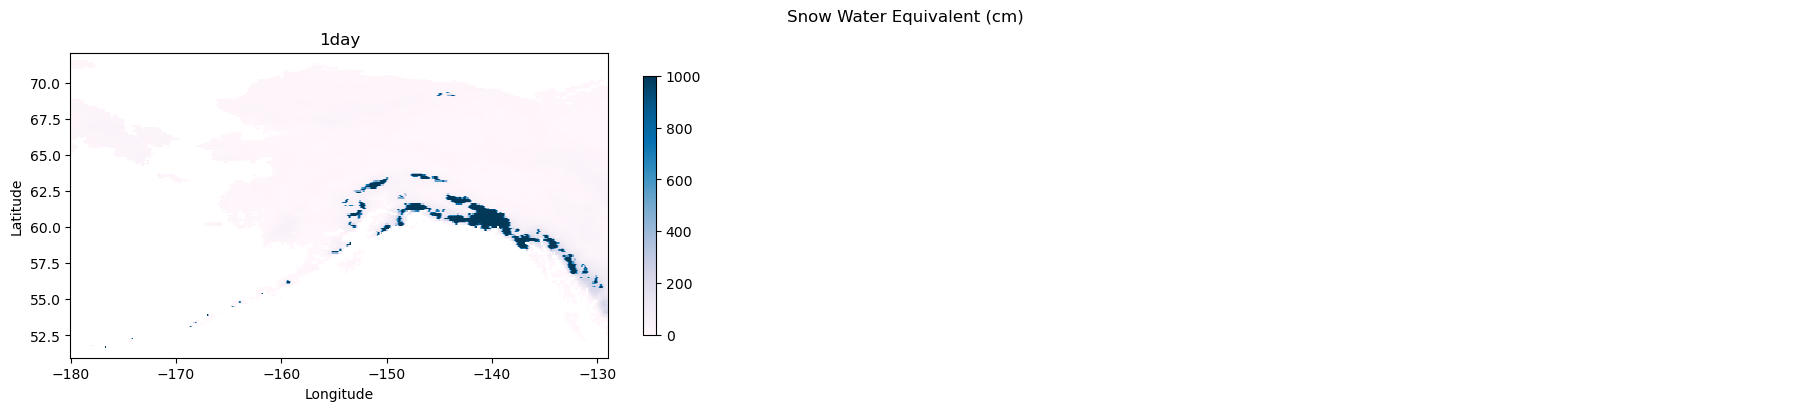

In [40]:
plot_variable_across_files(short_window_files, "swe")

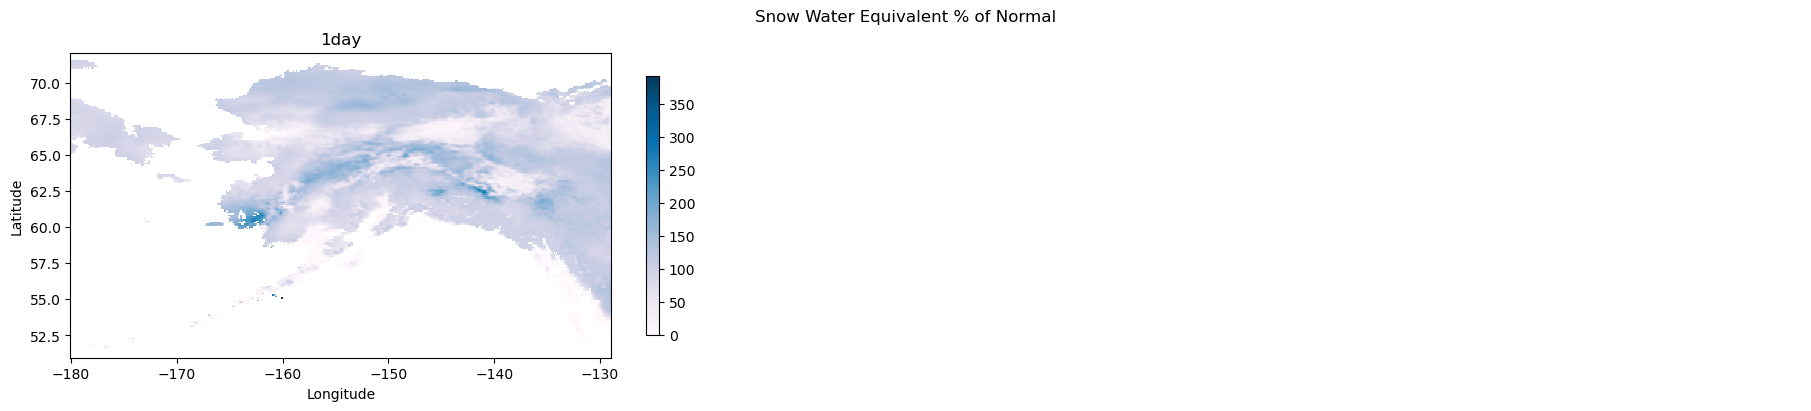

In [41]:
plot_variable_across_files(short_window_files, "pnswe")